# Macroeconomic Regime Prediction


## Strategy Motivation

In the previous notebooks, market regimes were identified using a Hidden Markov Model fitted to market-based features. Those labels are useful for understanding the structure of the sample, but they are still based on information observed at the current time. If the portfolio is rebalanced only after a regime is observed, the allocation change is necessarily reactive.

This notebook extends the project by using **macroeconomic data from FRED** to predict the **next month's HMM regime**. The HMM labels from Notebook 4 will serve as the supervised learning target, while a collection of macroeconomic indicators will be used as predictors.

The objective is not only to classify the next regime, but also to estimate **regime probabilities**. Those probabilities can then be used in the next notebook to build a forward-looking portfolio allocation.


## Load HMM Regimes and Build Monthly Targets


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

project_root = Path("..").resolve()
data_dir = project_root / "data"
results_dir = project_root / "results"
processed_dir = data_dir / "processed"
raw_dir = data_dir / "raw" / "fred"

raw_dir.mkdir(parents=True, exist_ok=True)


In [2]:
# Load daily HMM regime labels from Notebook 4

daily_regimes = pd.read_csv(results_dir / "market_regimes.csv", parse_dates=["Date"])
daily_regimes = daily_regimes.rename(columns={"Date": "decision_date"}).set_index("decision_date").sort_index()

daily_regimes.head()


,regime,regime_label
decision_date,,
2010-02-02,2,Neutral
2010-02-03,2,Neutral
2010-02-04,2,Neutral
2010-02-05,2,Neutral
2010-02-08,2,Neutral


In [3]:
# Convert daily regime labels into a monthly decision table

monthly_regime_targets = daily_regimes.groupby(daily_regimes.index.to_period("M")).tail(1).copy()
monthly_regime_targets["decision_month"] = monthly_regime_targets.index.to_period("M").to_timestamp("M")
monthly_regime_targets["holding_month"] = monthly_regime_targets["decision_month"] + pd.offsets.MonthEnd(1)
monthly_regime_targets = monthly_regime_targets.rename(columns={"regime_label": "current_regime", "regime": "current_state"})
monthly_regime_targets["next_regime"] = monthly_regime_targets["current_regime"].shift(-1)
monthly_regime_targets["next_state"] = monthly_regime_targets["current_state"].shift(-1)
monthly_regime_targets = monthly_regime_targets.dropna(subset=["next_regime"]).copy()
monthly_regime_targets.head()


,current_state,current_regime,decision_month,holding_month,next_regime,next_state
decision_date,,,,,,
2010-02-26,2,Neutral,2010-02-28,2010-03-31,Bull,1.0
2010-03-31,1,Bull,2010-03-31,2010-04-30,Neutral,2.0
2010-04-30,2,Neutral,2010-04-30,2010-05-31,Neutral,2.0
2010-05-28,2,Neutral,2010-05-31,2010-06-30,Neutral,2.0
2010-06-30,2,Neutral,2010-06-30,2010-07-31,Neutral,2.0


The table above provides the monthly supervised learning target. For each month-end decision date, the **current regime** is the HMM label observed at the final trading day of that month, and the **next regime** is the label observed at the end of the following month.

This creates a natural prediction problem for the machine learning models: use information available at month-end to estimate the regime that will prevail during the next rebalance period.


## Download and Prepare FRED Macroeconomic Data


In [4]:
# FRED series chosen to capture labor, inflation, activity, rates, credit, housing, and sentiment

fred_series = {
    "UNRATE": "Unemployment Rate",
    "CPIAUCSL": "Consumer Price Index",
    "FEDFUNDS": "Federal Funds Rate",
    "INDPRO": "Industrial Production Index",
    "PAYEMS": "Nonfarm Payrolls",
    "UMCSENT": "Consumer Sentiment",
    "GS10": "10-Year Treasury Yield",
    "TB3MS": "3-Month Treasury Bill Rate",
    "BAA": "Moody's BAA Corporate Bond Yield",
    "AAA": "Moody's AAA Corporate Bond Yield",
    "HOUST": "Housing Starts",
}


def download_fred_series(series_id, output_dir):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    response = requests.get(url, timeout=30)
    response.raise_for_status()

    path = output_dir / f"{series_id}.csv"
    path.write_text(response.text)

    df = pd.read_csv(path)
    df[series_id] = pd.to_numeric(df[series_id], errors="coerce")
    df["observation_date"] = pd.to_datetime(df["observation_date"])
    df = df.rename(columns={"observation_date": "date"}).set_index("date")
    df.index = df.index.to_period("M").to_timestamp("M")
    return df


fred_raw_frames = []
for series_id in fred_series:
    fred_raw_frames.append(download_fred_series(series_id, raw_dir))

fred_raw = pd.concat(fred_raw_frames, axis=1).sort_index()
fred_raw.tail()


,UNRATE,CPIAUCSL,FEDFUNDS,INDPRO,PAYEMS,UMCSENT,GS10,TB3MS,BAA,AAA,HOUST
date,,,,,,,,,,,
2025-11-30,4.5,325.063,3.88,101.0810,158449.0,51.0,4.09,3.78,5.86,5.26,1324.0
2025-12-31,4.4,326.031,3.72,101.6113,158432.0,52.9,4.14,3.59,5.90,5.31,1387.0
2026-01-31,4.3,326.588,3.64,101.5954,158592.0,56.4,4.21,3.57,5.88,5.34,1487.0
2026-02-28,4.4,327.460,3.64,102.3440,158459.0,56.6,4.13,3.60,5.81,5.30,NaN
2026-03-31,4.3,330.293,3.64,101.7898,158637.0,53.3,4.25,3.61,6.04,5.48,NaN


In [5]:
# Feature engineering

macro_features = pd.DataFrame(index=fred_raw.index)

macro_features["unemployment_rate"] = fred_raw["UNRATE"] / 100
macro_features["unemployment_change_3m"] = fred_raw["UNRATE"].diff(3) / 100
macro_features["inflation_yoy"] = fred_raw["CPIAUCSL"].pct_change(12)
macro_features["inflation_3m_annualized"] = (fred_raw["CPIAUCSL"] / fred_raw["CPIAUCSL"].shift(3)) ** 4 - 1
macro_features["fed_funds_rate"] = fred_raw["FEDFUNDS"] / 100
macro_features["industrial_production_yoy"] = fred_raw["INDPRO"].pct_change(12)
macro_features["payrolls_yoy"] = fred_raw["PAYEMS"].pct_change(12)
macro_features["consumer_sentiment"] = fred_raw["UMCSENT"]
macro_features["consumer_sentiment_change_3m"] = fred_raw["UMCSENT"].diff(3)
macro_features["term_spread"] = (fred_raw["GS10"] - fred_raw["TB3MS"]) / 100
macro_features["credit_spread"] = (fred_raw["BAA"] - fred_raw["AAA"]) / 100
macro_features["housing_starts_yoy"] = fred_raw["HOUST"].pct_change(12)

# Lag all macro features by one month to make the information set more conservative.
macro_features_lagged = macro_features.shift(1)
macro_features_lagged.tail()


/var/folders/66/r362bhns43b3951vfpzg29dr0000gn/T/ipykernel_66780/4058024905.py:7: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  macro_features["inflation_yoy"] = fred_raw["CPIAUCSL"].pct_change(12)
/var/folders/66/r362bhns43b3951vfpzg29dr0000gn/T/ipykernel_66780/4058024905.py:16: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  macro_features["housing_starts_yoy"] = fred_raw["HOUST"].pct_change(12)


,unemployment_rate,unemployment_change_3m,inflation_yoy,inflation_3m_annualized,fed_funds_rate,industrial_production_yoy,payrolls_yoy,consumer_sentiment,consumer_sentiment_change_3m,term_spread,credit_spread,housing_starts_yoy
date,,,,,,,,,,,,
2025-11-30,NaN,NaN,0.027291,NaN,0.0409,0.017593,0.002931,53.6,-8.1,0.0024,0.0061,-0.059172
2025-12-31,0.045,0.002,0.026964,0.022105,0.0388,0.018012,0.002341,51.0,-7.2,0.0031,0.0060,0.022394
2026-01-31,0.044,0.000,0.026533,0.022215,0.0372,0.012798,0.000733,52.9,-2.2,0.0055,0.0059,-0.083884
2026-02-28,0.043,NaN,0.023912,NaN,0.0364,0.015297,0.002047,56.4,2.8,0.0064,0.0054,0.094993
2026-03-31,0.044,-0.001,0.024340,0.029824,0.0364,0.012312,0.000941,56.6,5.6,0.0053,0.0051,-0.002013


The feature construction deliberately uses broad macroeconomic categories rather than a very large feature library. This keeps the first version of the supervised learning problem interpretable and closer in spirit to the earlier notebooks.

A one-month lag is applied to all features to reduce look-ahead risk. This is still a simplification, because different macroeconomic series have different publication lags, but it provides a conservative starting point that can later be extended with real-time vintage data from ALFRED if needed.


## Align Macro Features With Next-Month Regime Targets


In [6]:
model_data = monthly_regime_targets.set_index("decision_month").join(macro_features_lagged, how="left")
model_data = model_data.dropna().copy()

feature_cols = [col for col in model_data.columns if col not in ["current_state", "current_regime", "holding_month", "next_regime", "next_state"]]
regime_order = ["Bull", "Neutral", "Crisis"]

print("Model sample starts:", model_data.index.min().date())
print("Model sample ends:", model_data.index.max().date())
print("Number of monthly observations:", len(model_data))
print("Feature columns:")
print(feature_cols)


Model sample starts: 2010-02-28
Model sample ends: 2026-01-31
Number of monthly observations: 191
Feature columns:
['unemployment_rate', 'unemployment_change_3m', 'inflation_yoy', 'inflation_3m_annualized', 'fed_funds_rate', 'industrial_production_yoy', 'payrolls_yoy', 'consumer_sentiment', 'consumer_sentiment_change_3m', 'term_spread', 'credit_spread', 'housing_starts_yoy']


In [7]:
model_data[["current_regime", "next_regime"] + feature_cols].head()


,current_regime,next_regime,unemployment_rate,unemployment_change_3m,inflation_yoy,inflation_3m_annualized,fed_funds_rate,industrial_production_yoy,payrolls_yoy,consumer_sentiment,consumer_sentiment_change_3m,term_spread,credit_spread,housing_starts_yoy
decision_month,,,,,,,,,,,,,,
2010-02-28,Neutral,Bull,0.098,-0.002,0.026211,0.018210,0.0011,0.008723,-0.031899,74.4,3.8,0.0367,0.0099,0.253061
2010-03-31,Bull,Neutral,0.098,-0.001,0.021513,0.000866,0.0013,0.018708,-0.027093,73.6,6.2,0.0358,0.0099,0.037801
2010-04-30,Neutral,Neutral,0.099,0.000,0.022862,0.000110,0.0016,0.042007,-0.019835,73.6,1.1,0.0358,0.0100,0.259406
2010-05-31,Neutral,Neutral,0.099,0.001,0.022068,-0.001562,0.0020,0.054282,-0.012911,72.2,-2.2,0.0369,0.0096,0.437238
2010-06-30,Neutral,Neutral,0.096,-0.002,0.020035,0.000166,0.0020,0.079426,-0.006268,73.6,0.0,0.0326,0.0109,0.079630


## Model Setup

The prediction target is the **next month's regime**, and the models are estimated using an **expanding-window walk-forward procedure**. This mirrors the backtesting philosophy used in Notebook 6: each prediction is formed using only information that would have been available up to the decision month.

The following classifiers are compared:

- `Persistence`: predicts that the next regime will remain the same as the current regime
- `Logistic_Regression`: a simple multinomial benchmark with standardized features
- `Random_Forest`: a nonlinear tree-based classifier
- `Hist_Gradient_Boosting`: a boosted tree model designed for tabular data
- `Gaussian_NB`: a lightweight probabilistic baseline

Because the portfolio construction in the next notebook will use predicted probabilities rather than only hard class labels, **log loss** will be the primary model-selection metric, with accuracy used as a secondary check.


In [8]:
# Model definitions

def build_models():
    return {
        "Logistic_Regression": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42)),
        ]),
        "Random_Forest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=500,
                max_depth=4,
                min_samples_leaf=3,
                class_weight="balanced_subsample",
                random_state=42,
            )),
        ]),
        "Hist_Gradient_Boosting": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", HistGradientBoostingClassifier(
                max_depth=3,
                learning_rate=0.05,
                max_iter=250,
                random_state=42,
            )),
        ]),
        "Gaussian_NB": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", GaussianNB()),
        ]),
    }


def one_hot_probability(label, classes):
    probs = pd.Series(0.0, index=classes)
    probs[label] = 1.0
    return probs


def aligned_model_probabilities(fitted_model, X_test, classes):
    raw = fitted_model.predict_proba(X_test)[0]
    probs = pd.Series(0.0, index=classes)
    for label, value in zip(fitted_model.classes_, raw):
        probs[label] = value
    return probs


def multiclass_brier_score(y_true, prob_df, classes):
    y_indicator = pd.get_dummies(pd.Categorical(y_true, categories=classes))
    y_indicator = y_indicator.reindex(columns=classes, fill_value=0)
    return ((prob_df[classes].values - y_indicator.values) ** 2).sum(axis=1).mean()


In [9]:
# Walk-forward prediction loop

min_training_months = 60
predictions = []
models = build_models()

X_all = model_data[feature_cols]
y_all = model_data["next_regime"]

for i in range(min_training_months, len(model_data)):
    train = model_data.iloc[:i].copy()
    test = model_data.iloc[[i]].copy()

    X_train = train[feature_cols]
    y_train = train["next_regime"]
    X_test = test[feature_cols]

    base_record = {
        "decision_month": test.index[0],
        "decision_date": test.index[0],
        "holding_month": test["holding_month"].iloc[0],
        "current_regime": test["current_regime"].iloc[0],
        "actual_next_regime": test["next_regime"].iloc[0],
    }

    persistence_probs = one_hot_probability(base_record["current_regime"], regime_order)
    predictions.append({
        **base_record,
        "model": "Persistence",
        "predicted_regime": persistence_probs.idxmax(),
        **{f"p_{regime}": persistence_probs[regime] for regime in regime_order},
    })

    for model_name, model in models.items():
        fitted = clone(model)
        fitted.fit(X_train, y_train)
        probs = aligned_model_probabilities(fitted, X_test, regime_order)

        predictions.append({
            **base_record,
            "model": model_name,
            "predicted_regime": probs.idxmax(),
            **{f"p_{regime}": probs[regime] for regime in regime_order},
        })

predictions = pd.DataFrame(predictions)
predictions.head()


,decision_month,decision_date,holding_month,current_regime,actual_next_regime,model,predicted_regime,p_Bull,p_Neutral,p_Crisis
0,2015-02-28,2015-02-28,2015-03-31,Bull,Bull,Persistence,Bull,1.000000,0.000000,0.000000
1,2015-02-28,2015-02-28,2015-03-31,Bull,Bull,Logistic_Regression,Bull,0.771364,0.225939,0.002697
2,2015-02-28,2015-02-28,2015-03-31,Bull,Bull,Random_Forest,Bull,0.640785,0.355774,0.003441
3,2015-02-28,2015-02-28,2015-03-31,Bull,Bull,Hist_Gradient_Boosting,Bull,0.957766,0.042224,0.000010
4,2015-02-28,2015-02-28,2015-03-31,Bull,Bull,Gaussian_NB,Neutral,0.198634,0.801366,0.000000


## Walk-Forward Model Comparison


In [10]:
# Performance comparison

performance_rows = []
prob_cols = [f"p_{regime}" for regime in regime_order]

def safe_log_loss(y_true, prob_df, labels):
    probs = prob_df.loc[:, labels].copy().clip(1e-8, 1 - 1e-8)
    probs = probs.div(probs.sum(axis=1), axis=0)
    y_true = pd.Series(y_true).reset_index(drop=True)
    label_positions = y_true.map({label: i for i, label in enumerate(labels)})
    if label_positions.isna().any():
        missing = sorted(y_true[label_positions.isna()].unique())
        raise ValueError(f"Found labels not present in probability columns: {missing}")
    actual_probabilities = probs.to_numpy()[np.arange(len(y_true)), label_positions.astype(int).to_numpy()]
    return -np.log(actual_probabilities).mean()

for model_name, group in predictions.groupby("model"):
    probs = group[prob_cols].copy()
    probs.columns = regime_order

    performance_rows.append({
        "model": model_name,
        "accuracy": accuracy_score(group["actual_next_regime"], group["predicted_regime"]),
        "log_loss": safe_log_loss(group["actual_next_regime"], probs, regime_order),
        "brier_score": multiclass_brier_score(group["actual_next_regime"], probs, regime_order),
        "n_predictions": len(group),
    })

performance_table = pd.DataFrame(performance_rows).sort_values(["log_loss", "accuracy"], ascending=[True, False])
performance_table


,model,accuracy,log_loss,brier_score,n_predictions
4,Random_Forest,0.717557,0.709032,0.431696,131
2,Logistic_Regression,0.595420,1.146173,0.562322,131
1,Hist_Gradient_Boosting,0.679389,1.200657,0.515257,131
0,Gaussian_NB,0.648855,2.202539,0.608105,131
3,Persistence,0.793893,3.796629,0.412214,131


The table above compares the forecasting models on a true walk-forward basis. Accuracy is useful for checking how often the most likely regime is correct, but the portfolio application requires **well-calibrated probabilities**, so log loss and Brier score are especially important here. On this basis, `Random_Forest` is selected as the best macro regime model. The simple `Persistence` benchmark has the highest hard-label accuracy, but its one-hot probabilities are overconfident and therefore much worse by log loss.


In [11]:
# Best model selection

best_model_name = performance_table.iloc[0]["model"]
best_model_predictions = predictions.loc[predictions["model"] == best_model_name].copy()

print("Best model:", best_model_name)
print()
display(best_model_predictions.head())


Best model: Random_Forest



,decision_month,decision_date,holding_month,current_regime,actual_next_regime,model,predicted_regime,p_Bull,p_Neutral,p_Crisis
2,2015-02-28,2015-02-28,2015-03-31,Bull,Bull,Random_Forest,Bull,0.640785,0.355774,0.003441
7,2015-03-31,2015-03-31,2015-04-30,Bull,Bull,Random_Forest,Bull,0.566021,0.432167,0.001811
12,2015-04-30,2015-04-30,2015-05-31,Bull,Bull,Random_Forest,Bull,0.568653,0.431347,0.000000
17,2015-05-31,2015-05-31,2015-06-30,Bull,Bull,Random_Forest,Bull,0.779554,0.218626,0.001820
22,2015-06-30,2015-06-30,2015-07-31,Bull,Bull,Random_Forest,Bull,0.728448,0.164792,0.106761


In [12]:
# Confusion matrix for the best model

conf_mat = pd.DataFrame(
    confusion_matrix(
        best_model_predictions["actual_next_regime"],
        best_model_predictions["predicted_regime"],
        labels=regime_order,
    ),
    index=[f"Actual_{label}" for label in regime_order],
    columns=[f"Pred_{label}" for label in regime_order],
)

conf_mat


,Pred_Bull,Pred_Neutral,Pred_Crisis
Actual_Bull,73,12,1
Actual_Neutral,21,21,0
Actual_Crisis,1,2,0


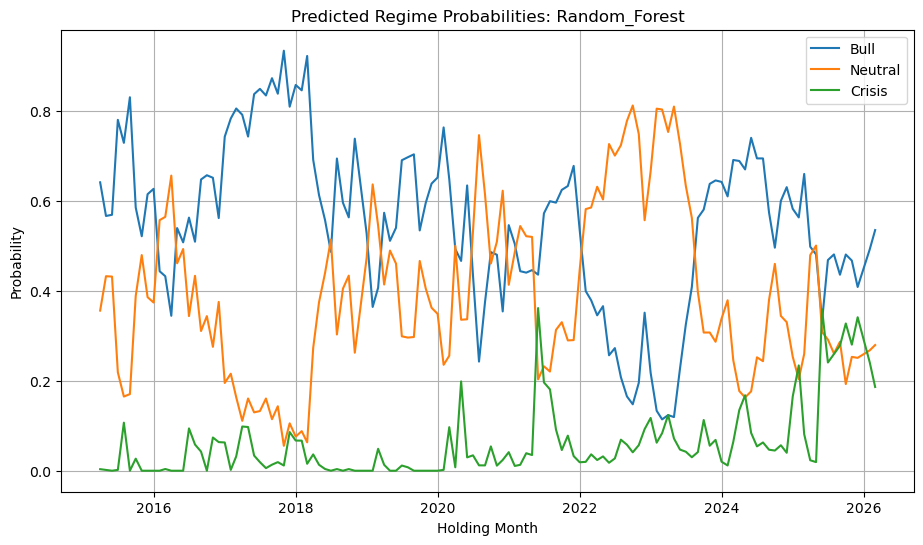

In [13]:
# Plot the predicted probabilities of the best model through time

plt.figure(figsize=(11, 6))
for regime in regime_order:
    plt.plot(best_model_predictions["holding_month"], best_model_predictions[f"p_{regime}"], label=regime)

plt.title(f"Predicted Regime Probabilities: {best_model_name}")
plt.xlabel("Holding Month")
plt.ylabel("Probability")
plt.legend()
plt.grid(True)
plt.show()


### Interpretation

The selected `Random_Forest` model provides the best probability forecasts among the tested models, even though it does not beat the persistence rule on simple accuracy. That trade-off is acceptable for the next notebook because the portfolio allocation will use the full probability distribution, not just the single most likely regime.

The confusion matrix shows that the model is strongest in Bull months and mixed in Neutral months. Crisis interpretation should remain cautious: there are very few Crisis observations in the walk-forward sample, and the selected model does not correctly classify any of them as Crisis. In this first version, Crisis probabilities are better read as a stress-risk signal than as a fully reliable crisis classifier.

The feature-importance diagnostic suggests the Random Forest relies most on labor-market growth, inflation, consumer sentiment, credit spreads, sentiment momentum, and the yield-curve term spread. These drivers are economically plausible, but tree-based importance should be interpreted as model usage rather than causal importance.


In [14]:
# Feature importance diagnostic for the best model fitted on the full sample

non_persistence_models = build_models()
feature_importance = None

if best_model_name != "Persistence":
    final_model = clone(non_persistence_models[best_model_name])
    final_model.fit(model_data[feature_cols], model_data["next_regime"])
    fitted_model = final_model.named_steps["model"]

    if hasattr(fitted_model, "feature_importances_"):
        importance_values = fitted_model.feature_importances_
    elif hasattr(fitted_model, "coef_"):
        importance_values = np.abs(fitted_model.coef_).mean(axis=0)
    else:
        importance_values = np.repeat(np.nan, len(feature_cols))

    feature_importance = pd.DataFrame({
        "feature": feature_cols,
        "importance": importance_values,
    }).sort_values("importance", ascending=False)

    display(feature_importance)


,feature,importance
6,payrolls_yoy,0.132893
2,inflation_yoy,0.118227
7,consumer_sentiment,0.116158
10,credit_spread,0.111470
8,consumer_sentiment_change_3m,0.089238
9,term_spread,0.085240
11,housing_starts_yoy,0.076112
0,unemployment_rate,0.065885
5,industrial_production_yoy,0.061617
3,inflation_3m_annualized,0.055712


In [15]:
# Sanity checks for Notebook 8 handoff

probability_sums = predictions[prob_cols].sum(axis=1)
available_models = set(predictions["model"].unique())

sanity_checks = pd.Series({
    "probabilities_sum_to_one": np.allclose(probability_sums, 1.0),
    "no_missing_probabilities": not predictions[prob_cols].isna().any().any(),
    "best_model_in_predictions": best_model_name in available_models,
    "best_model_predictions_present": not best_model_predictions.empty,
}, name="passed")

assert sanity_checks.all(), sanity_checks[sanity_checks == False]
display(sanity_checks)


probabilities_sum_to_one          True
no_missing_probabilities          True
best_model_in_predictions         True
best_model_predictions_present    True
Name: passed, dtype: bool

In [16]:
# Save processed data and model outputs

macro_features_lagged.to_csv(processed_dir / "fred_macro_features.csv")
monthly_regime_targets.reset_index().to_csv(results_dir / "monthly_hmm_regime_targets.csv", index=False)
predictions.to_csv(results_dir / "macro_regime_model_predictions.csv", index=False)
performance_table.to_csv(results_dir / "macro_regime_model_performance.csv", index=False)
conf_mat.to_csv(results_dir / "macro_regime_best_model_confusion_matrix.csv")

if feature_importance is not None:
    feature_importance.to_csv(results_dir / "macro_regime_best_model_feature_importance.csv", index=False)

metadata = {
    "target": "next_month_hmm_regime",
    "feature_source": "FRED",
    "feature_lag_months": 1,
    "best_model": best_model_name,
    "model_selection_metric": "log_loss",
    "regime_order": regime_order,
    "feature_columns": feature_cols,
    "min_training_months": min_training_months,
}

with open(results_dir / "macro_regime_model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4, default=str)


## Summary and Next Steps

This notebook converted the HMM market regimes into a supervised learning target and used lagged FRED macroeconomic indicators to predict the **next month's regime**. Multiple machine learning models were evaluated using a walk-forward expanding-window design, and `Random_Forest` was selected using **probability-sensitive metrics** rather than classification accuracy alone.

The next step is to take the validated `Random_Forest` regime probabilities and translate them into a forward-looking portfolio allocation. In the next notebook, those probabilities will be combined with regime-specific expected returns and covariance matrices to construct a macro-aware regime-switching strategy.
